<a href="https://colab.research.google.com/github/AiWriter404/AI-With-Python-Digiskills/blob/main/Ai_With_Python_W4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Topic 67 Outlier Detection Using Statistical Rules
# Load Dataset
import pandas as pd
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import pandas as pd
file_path='/content/drive/MyDrive/Ai_with_python/datasets/ecommerce_sales_analytics_5000.csv'
df=pd.read_csv(file_path)
df.head()

,order_id,order_date,customer_id,product_category,region,quantity,unit_price,discount,payment_method,delivery_days,customer_rating,revenue
0,10001,1/1/2022,1102,Beauty,South,7,373.65,0.28,Wallet,10,4.7,1883.20
1,10002,1/2/2022,1435,Clothing,South,7,47.74,0.09,Card,6,3.9,304.10
2,10003,1/3/2022,1860,Beauty,East,3,311.28,0.31,COD,6,2.5,644.35
3,10004,1/4/2022,1270,Electronics,West,5,524.47,0.02,Wallet,6,1.6,2569.90
4,10005,1/5/2022,1106,Clothing,West,5,139.87,0.33,Wallet,4,4.9,468.56


In [ ]:
df=pd.read_csv(file_path)
print(df.head())

   order_id order_date  customer_id product_category region  quantity  \
0     10001   1/1/2022         1102           Beauty  South         7   
1     10002   1/2/2022         1435         Clothing  South         7   
2     10003   1/3/2022         1860           Beauty   East         3   
3     10004   1/4/2022         1270      Electronics   West         5   
4     10005   1/5/2022         1106         Clothing   West         5   

   unit_price  discount payment_method  delivery_days  customer_rating  \
0      373.65      0.28         Wallet             10              4.7   
1       47.74      0.09           Card              6              3.9   
2      311.28      0.31            COD              6              2.5   
3      524.47      0.02         Wallet              6              1.6   
4      139.87      0.33         Wallet              4              4.9   

   revenue  
0  1883.20  
1   304.10  
2   644.35  
3  2569.90  
4   468.56  


In [ ]:
print(df.shape)
print(df.columns)

(5000, 12)
Index(['order_id', 'order_date', 'customer_id', 'product_category', 'region',
       'quantity', 'unit_price', 'discount', 'payment_method', 'delivery_days',
       'customer_rating', 'revenue'],
      dtype='object')


In [ ]:
# IQR method
Q1=df["revenue"].quantile(0.25)
Q3=df["revenue"].quantile(0.75)
IQR=Q3-Q1
lower_bound=Q1-1.5*IQR
upper_bound=Q3+1.5*IQR
outliers_iqr=df[(df["revenue"]<lower_bound) | (df["revenue"]>upper_bound)]
# IQR interquartile range: measures the middle 50% robust for skewed distribution (like revenue)

In [ ]:
# verify
outliers_iqr.shape

(67, 12)

In [ ]:
outliers_iqr[["revenue","product_category"]].head()

,revenue,product_category
39,3640.56,Home
69,3338.37,Beauty
102,3449.50,Clothing
126,3472.39,Clothing
157,3917.54,Electronics


In [ ]:
df=df[(df["revenue"] >=lower_bound) & (df["revenue"]<=upper_bound)]
df.shape

(4933, 12)

In [ ]:
# Z-score method
from scipy.stats import zscore
df=pd.read_csv(file_path)
df["revenue_zscore"]=zscore(df["revenue"])
outlier_z=df[df["revenue_zscore"].abs()>3]
# Z-score shows how much standard deviations a value is from the mean
# Rule:|Z| > 3 -> outlier

In [ ]:
outlier_z.shape

(26, 13)

In [ ]:
df=df[df["revenue_zscore"].abs() <=3]


NameError: name 'df' is not defined

In [ ]:
# Topic 68 Correlation & Covariance Analysis
import pandas as pd
from google.colab import drive
drive.mount('/content/drive')
file_path='/content/drive/MyDrive/Ai_with_python/datasets/ecommerce_sales_analytics_5000.csv'
df=pd.read_csv(file_path)
df.head()

Mounted at /content/drive


,order_id,order_date,customer_id,product_category,region,quantity,unit_price,discount,payment_method,delivery_days,customer_rating,revenue
0,10001,1/1/2022,1102,Beauty,South,7,373.65,0.28,Wallet,10,4.7,1883.20
1,10002,1/2/2022,1435,Clothing,South,7,47.74,0.09,Card,6,3.9,304.10
2,10003,1/3/2022,1860,Beauty,East,3,311.28,0.31,COD,6,2.5,644.35
3,10004,1/4/2022,1270,Electronics,West,5,524.47,0.02,Wallet,6,1.6,2569.90
4,10005,1/5/2022,1106,Clothing,West,5,139.87,0.33,Wallet,4,4.9,468.56


In [ ]:
# Covariance Metric
numeric_df=df[["quantity","unit_price","discount","delivery_days","revenue"]]
print("\nCovariance:\n",numeric_df.cov())
# covariance and corelation used only numerical columns


Covariance:
                   quantity    unit_price   discount  delivery_days  \
quantity          4.082009      0.512237  -0.000881      -0.055733   
unit_price        0.512237  28648.733946   0.226823       8.338403   
discount         -0.000881      0.226823   0.010283      -0.000122   
delivery_days    -0.055733      8.338403  -0.000122       9.943075   
revenue        1040.110589  94746.795528 -11.661466      14.172711   

                     revenue  
quantity         1040.110589  
unit_price      94746.795528  
discount          -11.661466  
delivery_days      14.172711  
revenue        681589.302978  


In [ ]:
# Correlation Matrix
print("\nCorrelation:\n",numeric_df.corr())


Correlation:
                quantity  unit_price  discount  delivery_days   revenue
quantity       1.000000    0.001498 -0.004302      -0.008748  0.623564
unit_price     0.001498    1.000000  0.013215       0.015623  0.678032
discount      -0.004302    0.013215  1.000000      -0.000382 -0.139296
delivery_days -0.008748    0.015623 -0.000382       1.000000  0.005444
revenue        0.623564    0.678032 -0.139296       0.005444  1.000000


In [ ]:
# Focus on Revenue Relationship
numeric_df.corr()["revenue"].sort_values(ascending=False)

,revenue
revenue,1.000000
unit_price,0.678032
quantity,0.623564
delivery_days,0.005444
discount,-0.139296


In [ ]:
# Verification
# Expected minimum > -1 and maximum < +1
numeric_df.corr().values.min(), numeric_df.corr().values.max()

(np.float64(-0.13929560296730714), np.float64(1.0))

In [ ]:
# Topic 69 Creating an Exploratory Data Analysis Report


**EDA Report**
Purpose of EDA Report
1. Summarize key insights from the data
2. Highlight Data Quality issues
3. Identfy Patterns, Distributions and Relationships
4. Include Tables, Figures Summary Statistics
5. Provide a checklist for further analysis

**Activit Goal**

1. Draft a 6 to 8 bullet point summary of your hypothetical EDA findings for a House Prices Dataset

**EDA Summary Points**

1. Comment on Data quality
2. Feature insights
3. Relationship between differnt attributes
4. Categorical insights
5. Outliers Anomolies
6. Temporal Patterns

**Key Takeaways**

1. EDA report = Narrative + visual evidence
2. Use Bullet Points for Clearity
3. Inlcude Tables, Figures and Key matrics
4. Document Assumptions, Anomalies, & Next step

**What is EDA Report**

1. A Short Narrative of Data insights
2. Combines tables, figures and bullet summaries
3. Guides preprocessing and modeling decisions
4. Ensure data quality befor ML
5. EDA report should be concize + structured
6. Use visuals and bullet points for clarity
7. Documents issues insights and next steps
8. Acts as a bridge between raw data and modeling

**Hands-On Examples 6-8 Bullet EDA Summary**


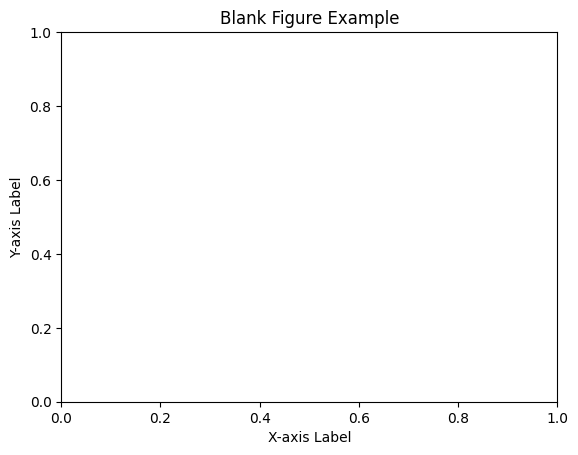

In [ ]:
# Topic 70 Matplotlib Figure Anatomy & Visualization Workflow
import matplotlib.pyplot as plt
# Object oriented workflow
fig, ax=plt.subplots()
# Label Axes
ax.set_title("Blank Figure Example")
ax.set_xlabel("X-axis Label")
ax.set_ylabel("Y-axis Label")
# Save the PNG
fig.savefig("blank_plot.png", dpi=100)
plt.show()

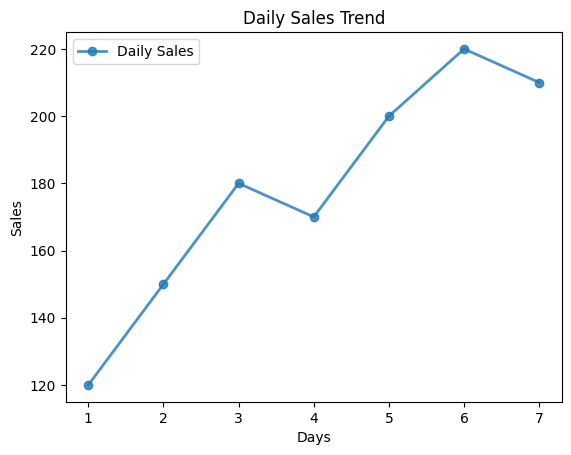

In [7]:
# Topic 71 Line & Scatter Plots Basics
import matplotlib.pyplot as plt
import pandas as pd
# sample data
days=[1,2,3,4,5,6,7]
sales=[120,150,180,170,200,220,210]
plt.plot(days,sales,
         marker='o',
         linewidth=2,
         alpha=0.8,
         label=("Daily Sales"))
plt.title("Daily Sales Trend")
plt.xlabel("Days")
plt.ylabel("Sales")
plt.legend()

plt.show()